# Module 3, Class 4 Assignment: Feature Selection

**Student:** Firdavs Boliev

This notebook completes the Module 3 Class 4 homework in a beginner-friendly way. The code cells include clear comments that explain what each step is doing.

## What this notebook covers
- Prepared numeric features and the binary churn target.
- Compared features using correlation and mutual information.
- Visualized mutual information scores in a bar chart.
- Used RFE to choose the top two features and compared model accuracy.


In [1]:
# This setup cell imports the libraries, loads the Telco dataset, and prepares TotalCharges as a numeric feature.
# === SETUP — run this first ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
print('Loaded:', df.shape)


Loaded: (7043, 21)


### Cell 1 — prepare X (features) and y (target)

In [2]:
# This cell creates the input features X and the target y that we want the model to predict.
df['Churn_bin'] = df['Churn'].map({'No': 0, 'Yes': 1})
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
X = df[num_cols]
y = df['Churn_bin']
print('X shape:', X.shape, '| y shape:', y.shape)


X shape: (7043, 4) | y shape: (7043,)


### Cell 2 — correlation between each feature and target

In [3]:
# This cell calculates how strongly each numeric feature is correlated with churn.
corr = X.copy()
corr['Churn'] = y
corr.corr()['Churn'].sort_values(ascending=False)


Churn             1.000000
MonthlyCharges    0.193356
SeniorCitizen     0.150889
TotalCharges     -0.198324
tenure           -0.352229
Name: Churn, dtype: float64

### Cell 3 — mutual information scores

In [4]:
# This cell uses mutual information to score features, including non-linear relationships with churn.
from sklearn.feature_selection import mutual_info_classif
mi = mutual_info_classif(X, y, random_state=42)
mi_scores = pd.Series(mi, index=X.columns).sort_values(ascending=False)
mi_scores.round(4)


tenure            0.0706
MonthlyCharges    0.0467
TotalCharges      0.0447
SeniorCitizen     0.0103
dtype: float64

### Cell 4 — bar chart of mutual information scores

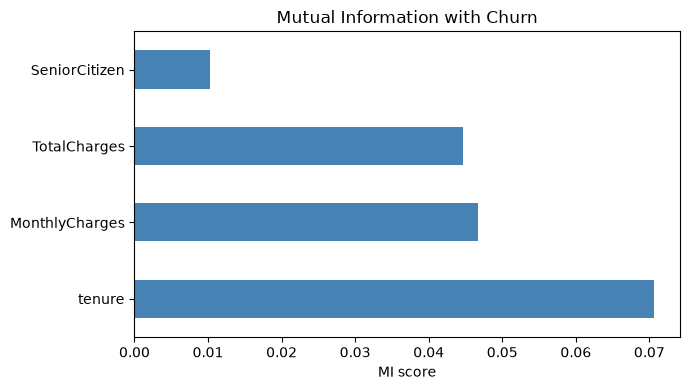

In [5]:
# This cell plots the mutual information scores so the strongest features are easier to compare visually.
plt.figure(figsize=(7, 4))
mi_scores.plot(kind='barh', color='steelblue')
plt.title('Mutual Information with Churn')
plt.xlabel('MI score')
plt.tight_layout()
plt.show()


### Cell 5 — RFE: pick the top 2 features using LogisticRegression

In [6]:
# This cell scales the features and uses RFE with LogisticRegression to select the top two features.
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
X_scaled = StandardScaler().fit_transform(X)
rfe = RFE(LogisticRegression(max_iter=1000), n_features_to_select=2)
rfe.fit(X_scaled, y)
result = pd.DataFrame({'feature': X.columns, 'kept': rfe.support_, 'rank': rfe.ranking_})
result.sort_values('rank')


,feature,kept,rank
0,tenure,True,1
1,MonthlyCharges,True,1
2,TotalCharges,False,2
3,SeniorCitizen,False,3


### Cell 6 — train a model with ALL features vs top 2 features

In [7]:
# This cell compares a model trained with all features against a model trained with only the selected top features.
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
m_all = LogisticRegression(max_iter=1000).fit(X_train, y_train)
print('All features accuracy:', round(accuracy_score(y_test, m_all.predict(X_test)), 4))
top_idx = np.where(rfe.support_)[0]
m_top = LogisticRegression(max_iter=1000).fit(X_train[:, top_idx], y_train)
print('Top 2 features accuracy:', round(accuracy_score(y_test, m_top.predict(X_test[:, top_idx])), 4))


All features accuracy: 0.8062
Top 2 features accuracy: 0.7984
